In [7]:
import tensorflow as tf
from tensorflow import keras

import os
import random

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.metrics

# discontinued import tensorflow_addons as tfa
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.models import load_model

In [9]:
base_dir = r"D:\ML_OCT_RS\Dataset"
print('Base directory --> ', os.listdir(base_dir))

Base directory -->  ['test', 'train', 'val']


In [11]:
# NOT EXCHANGED

train_dir = os.path.join(base_dir + "/train/")
print("Train Directory --> ", os.listdir(train_dir))

validation_dir = os.path.join(base_dir + "/val/")
print("Validation Directory --> ", os.listdir(validation_dir))

test_dir = os.path.join(base_dir + "/test/")
print("Test Directory --> ", os.listdir(test_dir))

Train Directory -->  ['CNV', 'DME', 'DRUSEN', 'NORMAL']
Validation Directory -->  ['CNV', 'DME', 'DRUSEN', 'NORMAL']
Test Directory -->  ['CNV', 'DME', 'DRUSEN', 'NORMAL']


In [13]:
cnv = len(os.listdir(os.path.join(train_dir + "/CNV")))
dme = len(os.listdir(os.path.join(train_dir + "/DME")))
drusen = len(os.listdir(os.path.join(train_dir + "/DRUSEN")))
normal = len(os.listdir(os.path.join(train_dir + "/NORMAL")))

counts = [cnv, dme, drusen, normal]

In [15]:
from sklearn.utils import class_weight
import numpy as np

class_counts = np.array(counts)
class_labels = np.array([0, 1, 2, 3])  # [CNV -> 0, DME -> 1, DRUSEN -> 2, NORMAL -> 3]

# Calculate class weights
weights = class_weight.compute_class_weight(class_weight='balanced', 
                                            classes=class_labels, 
                                            y=np.repeat(class_labels, class_counts))
class_weights = dict(enumerate(weights))

print("Class Weights:", class_weights)


Class Weights: {0: 0.7296037073766115, 1: 2.356337767923134, 2: 3.082299387689333, 3: 0.5317529814027188}


In [17]:
img_size = (224, 224)
batch_size = 32

# Load train and validation datasets
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='categorical',
    class_names=['CNV', 'DME', 'DRUSEN', 'NORMAL'],
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42,
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    validation_dir,
    labels='inferred',
    label_mode='categorical',
    class_names=['CNV', 'DME', 'DRUSEN', 'NORMAL'],
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42,
)

Found 76515 files belonging to 4 classes.
Found 21861 files belonging to 4 classes.


In [19]:
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='categorical',
    class_names=['CNV', 'DME', 'DRUSEN', 'NORMAL'],
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

Found 10933 files belonging to 4 classes.


In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),   
    batch_size=500,
    class_mode='categorical'
)

val_datagen = ImageDataGenerator(rescale=1./255)

validation_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical'
)

Found 76515 images belonging to 4 classes.
Found 21861 images belonging to 4 classes.


In [22]:
from tensorflow.keras.applications import InceptionV3
inc = InceptionV3(input_shape=(224,224,3),weights='imagenet',include_top=False)
for i in inc.layers:
    i.trainable = False
print(inc.summary())

Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 111, 111,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 111, 111,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 109, 109,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 54, 54,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 54, 54,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 52, 52,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 21,802,784 (83.17 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 21,802,784 (83.17 MB)

None


In [25]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, Flatten

model = tf.keras.models.Sequential([
    inc,
    Flatten(),
    tf.keras.layers.Dense(4, activation = 'softmax')
])

In [27]:
metrics = ['accuracy',
                tf.keras.metrics.AUC(),
               # tfa.metrics.CohenKappa(num_classes = 4),
               # tfa.metrics.F1Score(num_classes = 4),
                tf.keras.metrics.Precision(), 
                tf.keras.metrics.Recall()]
model.compile(loss =tf.keras.losses.CategoricalCrossentropy(), optimizer = 'adam', metrics = metrics)
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │       204,804 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,007,588 (83.95 MB)

 Trainable params: 204,804 (800.02 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

None


In [29]:
from tensorflow.keras.callbacks import EarlyStopping


early_stopping = EarlyStopping(
    monitor='val_loss',    
    patience=5,           
    restore_best_weights=True 
)

In [37]:
# import numpy as np
# import matplotlib.pyplot as plt
# import seaborn as sns
# from tensorflow.keras.models import load_model
# from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# # Load trained model
# model_path = "D:\ML_OCT_RS\Class_Weights.h5"   # Update if different
# model = load_model(model_path)

# # Load test data generator (assuming ImageDataGenerator was used)
# test_dir = "D:\ML_OCT_RS\Dataset" # Update if needed
# test_datagen = ImageDataGenerator(rescale=1./255)
# test_generator = test_datagen.flow_from_directory(
#     test_dir,
#     target_size=(299, 299),  # InceptionV3 default input size
#     batch_size=32,
#     class_mode='categorical',
#     shuffle=False
# )

# # Get ground truth labels
# y_true = test_generator.classes
# class_labels = list(test_generator.class_indices.keys())

# # Get model predictions
# y_pred_prob = model.predict(test_generator)
# y_pred = np.argmax(y_pred_prob, axis=1)

# # Classification report
# print("Classification Report:\n", classification_report(y_true, y_pred, target_names=class_labels))

# # Confusion Matrix
# conf_matrix = confusion_matrix(y_true, y_pred)
# plt.figure(figsize=(8,6))
# sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
# plt.xlabel("Predicted Label")
# plt.ylabel("True Label")
# plt.title("Confusion Matrix")
# plt.show()

# # ROC and AUC (for multi-class, one-vs-rest approach)
# plt.figure(figsize=(8,6))
# for i in range(len(class_labels)):
#     fpr, tpr, _ = roc_curve(y_true == i, y_pred_prob[:, i])
#     roc_auc = auc(fpr, tpr)
#     plt.plot(fpr, tpr, label=f'{class_labels[i]} (AUC = {roc_auc:.2f})')
# plt.plot([0, 1], [0, 1], 'k--')
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")
# plt.title("ROC Curves")
# plt.legend()
# plt.show()

# # Accuracy and Loss Curves (if history object is available)
# try:
#     import pickle
#     with open("history.pkl", "rb") as f:
#         history = pickle.load(f)
    
#     plt.figure(figsize=(12, 5))
#     plt.subplot(1, 2, 1)
#     plt.plot(history['accuracy'], label='Train Accuracy')
#     plt.plot(history['val_accuracy'], label='Validation Accuracy')
#     plt.xlabel("Epochs")
#     plt.ylabel("Accuracy")
#     plt.title("Accuracy Curve")
#     plt.legend()
    
#     plt.subplot(1, 2, 2)
#     plt.plot(history['loss'], label='Train Loss')
#     plt.plot(history['val_loss'], label='Validation Loss')
#     plt.xlabel("Epochs")
#     plt.ylabel("Loss")
#     plt.title("Loss Curve")
#     plt.legend()
    
#     plt.show()
# except FileNotFoundError:
#     print("No history.pkl file found. Skipping accuracy/loss plots.")


Found 10933 images belonging to 4 classes.
342/342 ━━━━━━━━━━━━━━━━━━━━ 261s 757ms/step
Classification Report:
               precision    recall  f1-score   support

         CNV       0.93      0.92      0.93      3746
         DME       0.81      0.82      0.82      1161
      DRUSEN       0.59      0.65      0.62       887
      NORMAL       0.95      0.94      0.94      5139

    accuracy                           0.90     10933
   macro avg       0.82      0.83      0.83     10933
weighted avg       0.90      0.90      0.90     10933



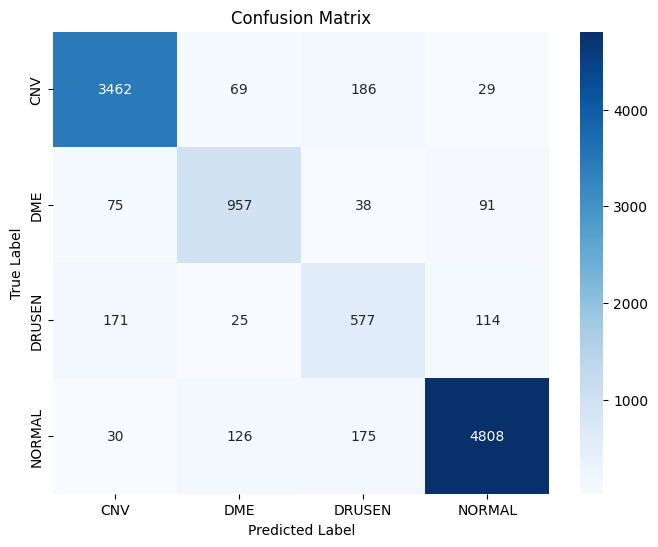

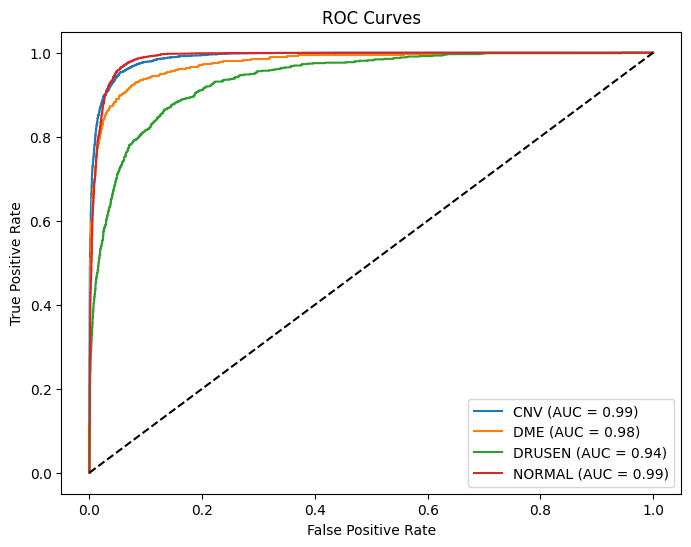

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Load trained model (without compiling to avoid loss function errors)
model_path = r"D:\ML_OCT_RS\Class_Weights.h5"
model = load_model(model_path, compile=False)

# Load test data generator
test_dir = r"D:\ML_OCT_RS\Dataset\test"
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),  # InceptionV3 default input size
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# Get ground truth labels
y_true = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Get model predictions
y_pred_prob = model.predict(test_generator)
y_pred = np.argmax(y_pred_prob, axis=1)

# Classification report
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=class_labels))

# Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# ROC and AUC (for multi-class, one-vs-rest approach)
plt.figure(figsize=(8,6))
for i in range(len(class_labels)):
    fpr, tpr, _ = roc_curve(y_true == i, y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{class_labels[i]} (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()
